# 07 · Classification validation (no retraining)

The production model is a **regressor** (XGBoost, `historical_lead`, test R² 0.5924). This
notebook validates it as a **classifier by thresholding** — Route A, exactly the greenlight
verdict the Streamlit app renders today. No new models are trained and `models/` is untouched.

Two tasks:

| task | label | positive share (test) |
|---|---|---|
| **binary greenlight** | `revenue >= 2.5 * budget` (i.e. `roi >= 1.5`) | 38% |
| **4 revenue tiers** | `< $25M / $25-100M / $100-500M / >= $500M` | 49/25/20/6% |

Same frozen protocol: time split ≤2016 / 2017–2021 / ≥2022 and encoders fit on train only.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.prepare_dataset import prepare_ml_dataset
from scripts.evaluation import (
    FEATURE_SETS, _split_matrices, time_split, greenlight_label,
    binary_threshold_metrics, tune_greenlight_offset,
    revenue_tier, tier_metrics, REVENUE_TIERS,
)
from scripts.models.predict import load_pipeline

ds = prepare_ml_dataset()
X_train, X_val, X_test, y_train, y_val, y_test = _split_matrices(ds, FEATURE_SETS['historical_lead'])
_, val0, test0 = time_split(ds)
rev_val, bud_val = val0['revenue'].to_numpy(), val0['budget'].to_numpy()
rev_test, bud_test = test0['revenue'].to_numpy(), test0['budget'].to_numpy()

model = load_pipeline()['model']
pred_val = model.predict(X_val)   # log1p revenue
pred_test = model.predict(X_test)

print('test rows:', len(rev_test), '| greenlight share: %.3f' % greenlight_label(rev_test, bud_test).mean())

test rows: 862 | greenlight share: 0.377


### Binary: greenlight (revenue ≥ 2.5× budget)

The model's predicted revenue is compared to the hurdle directly (the **natural cutoff**), then
an additive log-space **offset is tuned on validation** (max F1) and applied on test.

In [2]:
natural_val = binary_threshold_metrics(y_val, pred_val, rev_val, bud_val)
natural_test = binary_threshold_metrics(y_test, pred_test, rev_test, bud_test)

best_offset, tuned_val = tune_greenlight_offset(y_val, pred_val, rev_val, bud_val)
hurdle = np.log1p(bud_test * 2.5)
tuned_test = binary_threshold_metrics(y_test, pred_test + best_offset, rev_test, bud_test)

share_neg = 1 - greenlight_label(rev_test, bud_test).mean()
bl = dict(accuracy=share_neg, precision=0.0, recall=0.0, f1=0.0, roc_auc=0.5, pr_auc=0.0)

table = pd.DataFrame({
    'val · natural': natural_val,
    'val · tuned': tuned_val,
    'test · natural': natural_test,
    'test · tuned': tuned_test,
    'test · majority baseline': bl,
}).round(3)
table

,val · natural,val · tuned,test · natural,test · tuned,test · majority baseline
accuracy,0.684,0.644,0.713,0.642,0.623
precision,0.673,0.584,0.618,0.516,0.000
recall,0.631,0.832,0.628,0.797,0.000
f1,0.651,0.686,0.623,0.626,0.000
roc_auc,0.525,NaN,0.511,0.511,0.500
pr_auc,0.526,NaN,0.432,0.432,0.000
offset,NaN,0.300,NaN,NaN,NaN


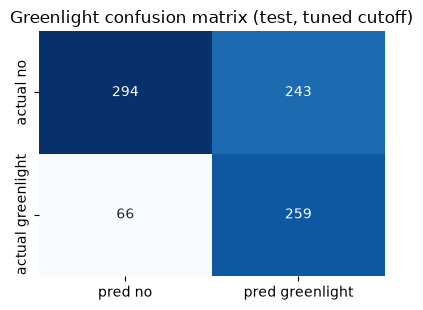

chosen val offset: +0.30


In [3]:
from sklearn.metrics import confusion_matrix
y_true = greenlight_label(rev_test, bud_test).astype(int)
pred = (pred_test + best_offset >= np.log1p(bud_test * 2.5)).astype(int)
cm = pd.DataFrame(confusion_matrix(y_true, pred),
                  index=['actual no', 'actual greenlight'],
                  columns=['pred no', 'pred greenlight'])
fig, ax = plt.subplots(figsize=(4, 3.2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_title('Greenlight confusion matrix (test, tuned cutoff)')
plt.tight_layout()
plt.savefig('../reports/figures/classification_binary_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('chosen val offset: %+.2f' % best_offset)

### Multiclass: four revenue tiers

The regression's predicted revenue is mapped to the nearest band; no retraining, no per-class
probability model. Compared against always predicting the test's most common tier.

In [4]:
tier_test = tier_metrics(y_test, pred_test, rev_test)

labels = [t[2] for t in REVENUE_TIERS]
actual_tier = revenue_tier(rev_test)
majority_tier = actual_tier.mode().iloc[0]
pred_majority = pd.Series(majority_tier, index=actual_tier.index)

from sklearn.metrics import f1_score
b_acc = float((actual_tier == majority_tier).mean())
b_f1 = f1_score(actual_tier, pred_majority, labels=labels, average='macro', zero_division=0)
tier_rows = {
    'accuracy': tier_test['accuracy'],
    'balanced_accuracy': tier_test['balanced_accuracy'],
    'macro_f1': tier_test['macro_f1'],
    'weighted_f1': tier_test['weighted_f1'],
    'majority_baseline_accuracy': b_acc,
    'majority_baseline_macro_f1': b_f1,
}
pd.Series(tier_rows).round(3)

accuracy                      0.607
balanced_accuracy             0.557
macro_f1                      0.564
weighted_f1                   0.616
majority_baseline_accuracy    0.486
majority_baseline_macro_f1    0.164
dtype: float64

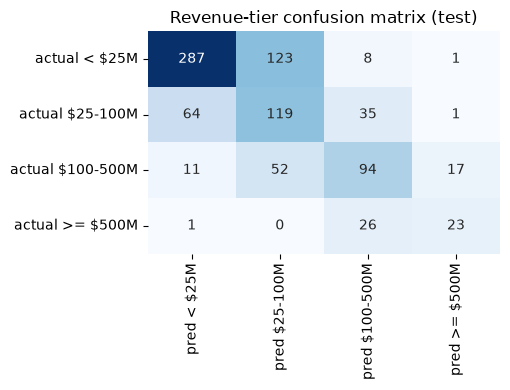

In [5]:
fig, ax = plt.subplots(figsize=(5.2, 4))
sns.heatmap(tier_test['confusion'].astype(int), annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_title('Revenue-tier confusion matrix (test)')
plt.tight_layout()
plt.savefig('../reports/figures/classification_tiers_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
from pathlib import Path
summary = pd.DataFrame({
    'task': ['greenlight'] * 5 + ['tiers'] * 4,
    'metric': ['accuracy', 'precision', 'recall', 'f1', 'roc_auc',
               'accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1'],
    'test_value': [
        tuned_test['accuracy'], tuned_test['precision'], tuned_test['recall'],
        tuned_test['f1'], tuned_test['roc_auc'],
        tier_test['accuracy'], tier_test['balanced_accuracy'],
        tier_test['macro_f1'], tier_test['weighted_f1'],
    ],
})
out = Path('../reports') / 'classification_metrics.csv'
out.parent.mkdir(exist_ok=True)
summary.to_csv(out, index=False)
print('wrote', out.resolve())

wrote /Users/hariz/Desktop/TMDB-movie-analysis/reports/classification_metrics.csv


### Verdict

**Can the existing regression be used for classification? Two very different answers:**

- **4-tier sorter — usable.** accuracy 0.607 vs 0.486 majority baseline, macro-F1 0.564 vs 0.164.
  The regressor separates broad revenue bands reasonably.
- **Greenlight hurdle (≥ 2.5× budget) — effectively a coin flip.** test ROC-AUC **0.511** (corr
  between predicted revenue and the label is only 0.06). Why: the model predicts *absolute*
  revenue well (R² 0.59, r=0.78 with actual), but both the prediction and the hurdle scale with
  **budget**, so predicted revenue sits at ~**1.03× the hurdle on average** — every movie lands
  right at the decision boundary, where residual noise decides the class. (An upper bound:
  using the *actual* log-revenue as a score yields AUC 0.76, so the label is classifiable —
  but not from this model's predictions.)

**Implication:** the app's greenlight verdict (this thresholded model) should be treated as a
no-better-than-coin-flip signal. A **dedicated classifier** trained directly on the
greenlight target (Route B) is the way to get a trustworthy go/no-go signal — this notebook
is the evidence for that decision.